# Evaluación Parcial N°4: Preprocesamiento de Datos

**Asignatura:** ADY1100 - Preprocesamiento de Datos

**Integrantes del Equipo:**
- Benjamín Martínez (Parte 1: Limpieza y Tratamiento de Nulos)
- Cristóbal González (Parte 2: Escalamiento y Codificación)
- **Javier Cataldo (Parte 3: Ingeniería de Características)**

## Objetivo

En esta etapa final de la evaluación 4, estoy encargado de aplicar técnicas de **ingeniería de características (feature engineering)** sobre los datasets de Órdenes y Artículos del e-commerce brasileño Olist. El objetivo de este proceso es generar nuevas variables a partir de los datos existentes, utilizando transformaciones matemáticas, condicionales y agregaciones, para enriquecer el conjunto de datos y mejorar la capacidad predictiva de los futuros modelos de Machine Learning.

## Nuevas Variables a Crear

| Variable | Tipo | Descripción | Técnica Aplicada |
|----------|------|-------------|------------------|
| `dias_espera` | Numérica continua | Días transcurridos entre la compra y la entrega real | Transformación matemática de fechas (resta) |
| `es_atrasado` | Binaria (0/1) | Indica si la entrega real superó la fecha estimada | Condicional / Interacción lógica |
| `costo_total_item` | Numérica continua | Suma del precio del producto más el costo de envío | Agregación matemática (suma) |

## Librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuracion visual global para todos los graficos
plt.rcParams['figure.figsize'] = (14, 6)  
plt.rcParams['font.size'] = 12            
plt.rcParams['axes.titlesize'] = 14       
sns.set_style('whitegrid')                
sns.set_palette('husl')                   

print('Librerias importadas y configuradas correctamente.')

Librerias importadas y configuradas correctamente.


## Carga de datos

In [2]:
# Cargamos los datasets desde la carpeta data/01_raw/
df_orders = pd.read_csv('../data/01_raw/olist_orders_dataset.csv')
df_items = pd.read_csv('../data/01_raw/olist_order_items_dataset.csv')

# Verificamos las dimensiones de los datasets cargados
print('Dimensiones de los datasets cargados:')
print(f'  olist_orders_dataset: {df_orders.shape[0]:,} filas x {df_orders.shape[1]} columnas')
print(f'  olist_order_items_dataset: {df_items.shape[0]:,} filas x {df_items.shape[1]} columnas')

Dimensiones de los datasets cargados:
  olist_orders_dataset: 99,441 filas x 8 columnas
  olist_order_items_dataset: 112,650 filas x 7 columnas


## Conversion de fechas

In [3]:
# Las columnas de fecha vienen como texto (string). Las convertimos a formato datetime
# para poder realizar operaciones matematicas (restas, comparaciones) entre ellas.
df_orders['order_purchase_timestamp'] = pd.to_datetime(df_orders['order_purchase_timestamp'])
df_orders['order_delivered_customer_date'] = pd.to_datetime(df_orders['order_delivered_customer_date'])
df_orders['order_estimated_delivery_date'] = pd.to_datetime(df_orders['order_estimated_delivery_date'])

print('\nColumnas de fecha convertidas a formato datetime correctamente.')
print('\nPrimeras 3 filas del dataset de ordenes:')
display(df_orders.head(3))
print('\nPrimeras 3 filas del dataset de items:')
display(df_items.head(3))


Columnas de fecha convertidas a formato datetime correctamente.

Primeras 3 filas del dataset de ordenes:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04



Primeras 3 filas del dataset de items:


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87


## Variables Nuevas

A continuación se detalla cada variable creada:

### 1. dias_espera — Días de espera del cliente
- **Qué hace:** Resta la fecha de compra a la fecha de entrega real.
- **Por qué:** Convierte dos fechas en un solo número (días) que el modelo sí puede entender.
- **Utilidad:** Sirve para medir satisfacción del cliente y predecir recompra.

### 2. es_atrasado — ¿Llegó atrasado? (0 o 1)
- **Qué hace:** Compara fecha de entrega real vs fecha estimada. Si pasó la fecha estimada, es atrasado (1).
- **Por qué:** Simplifica una comparación de fechas en un sí/no que cualquier modelo entiende.
- **Utilidad:** Sirve para clasificar órdenes atrasadas y medir cumplimiento logístico.

### 3. costo_total_item — Gasto real por producto
- **Qué hace:** Suma el precio del producto más el costo de envío.
- **Por qué:** El modelo no necesita aprender la relación entre precio y envío separadamente.
- **Utilidad:** Representa el gasto real del cliente. Sirve para calcular valor de cliente (CLV).


# CREACION DE NUEVAS VARIABLES (FEATURE ENGINEERING)

## PASO 1: LIMPIEZA PREVIA DEL DATASET DE ORDENES

#### Eliminamos las filas donde no hay fecha de entrega real, esto incluye ordenes canceladas o que aun no han sido entregadas. No tendria sentido calcular dias de espera o atraso en ordenes que nunca se entregaron.

In [4]:
print('=== PROCESO DE CREACION DE VARIABLES ===')
print(f'\nOrdenes antes de limpiar: {df_orders.shape[0]:,}')

df_orders = df_orders.dropna(subset=['order_delivered_customer_date']).copy()

print(f'Ordenes despues de limpiar (con entrega real): {df_orders.shape[0]:,}')
print(f'  - Se eliminaron ordenes sin fecha de entrega (canceladas/en proceso)')

=== PROCESO DE CREACION DE VARIABLES ===

Ordenes antes de limpiar: 99,441
Ordenes despues de limpiar (con entrega real): 96,476
  - Se eliminaron ordenes sin fecha de entrega (canceladas/en proceso)


# PASO 2: CREACION DE VARIABLE 1 - DIAS DE ESPERA

#### Restamos la fecha de compra a la fecha de entrega real, el resultado .dt.days nos da la diferencia en dias enteros.

In [5]:
df_orders['dias_espera'] = (df_orders['order_delivered_customer_date'] 
                            - df_orders['order_purchase_timestamp']).dt.days

print(f'Variable 1 - dias_espera:')
print(f'  - Media: {df_orders["dias_espera"].mean():.1f} dias')
print(f'  - Mediana: {df_orders["dias_espera"].median():.1f} dias')
print(f'  - Minimo: {df_orders["dias_espera"].min():.1f} dias')
print(f'  - Maximo: {df_orders["dias_espera"].max():.1f} dias')
print(f'  - Desviacion estandar: {df_orders["dias_espera"].std():.1f} dias')

Variable 1 - dias_espera:
  - Media: 12.1 dias
  - Mediana: 10.0 dias
  - Minimo: 0.0 dias
  - Maximo: 209.0 dias
  - Desviacion estandar: 9.6 dias


# PASO 3: CREACION DE VARIABLE 2 - ES ATRASADO (BINARIA)

#### Comparamos la fecha de entrega real con la fecha estimada
#### Si la entrega real > fecha estimada -> atrasado (1)
#### Si la entrega real <= fecha estimada -> a tiempo (0)

In [6]:
df_orders['es_atrasado'] = np.where(
    df_orders['order_delivered_customer_date'] > df_orders['order_estimated_delivery_date'],
    1,  # Atrasado
    0   # A tiempo
)
atrasados = df_orders['es_atrasado'].sum()
total = len(df_orders)
print(f'Variable 2 - es_atrasado:')
print(f'  - Pedidos a tiempo (0): {total - atrasados:,} ({(1 - atrasados/total)*100:.1f}%)')
print(f'  - Pedidos atrasados (1): {atrasados:,} ({atrasados/total*100:.1f}%)')

Variable 2 - es_atrasado:
  - Pedidos a tiempo (0): 88,649 (91.9%)
  - Pedidos atrasados (1): 7,827 (8.1%)


# PASO 4: CREACION DE VARIABLE 3 - COSTO TOTAL POR ITEM

#### Sumamos el precio del producto mas el costo de envio, esto consolida el gasto real del cliente en una sola columna.

In [7]:
df_items['costo_total_item'] = df_items['price'] + df_items['freight_value']
print(f'Variable 3 - costo_total_item:')
print(f'  - Media: ${df_items["costo_total_item"].mean():.2f}')
print(f'  - Mediana: ${df_items["costo_total_item"].median():.2f}')
print(f'  - Minimo: ${df_items["costo_total_item"].min():.2f}')
print(f'  - Maximo: ${df_items["costo_total_item"].max():.2f}')
print(f'  - Desviacion estandar: ${df_items["costo_total_item"].std():.2f}')

Variable 3 - costo_total_item:
  - Media: $140.64
  - Mediana: $92.32
  - Minimo: $6.08
  - Maximo: $6929.31
  - Desviacion estandar: $190.72


# VISUALIZACION DE RESULTADOS - 5 GRAFICOS

## GRAFICO 1: Distribucion de Dias de Espera

#### Muestra como se distribuyen los tiempos de entrega.
#### Una cola larga hacia la derecha indicaria pedidos con demoras significativas.

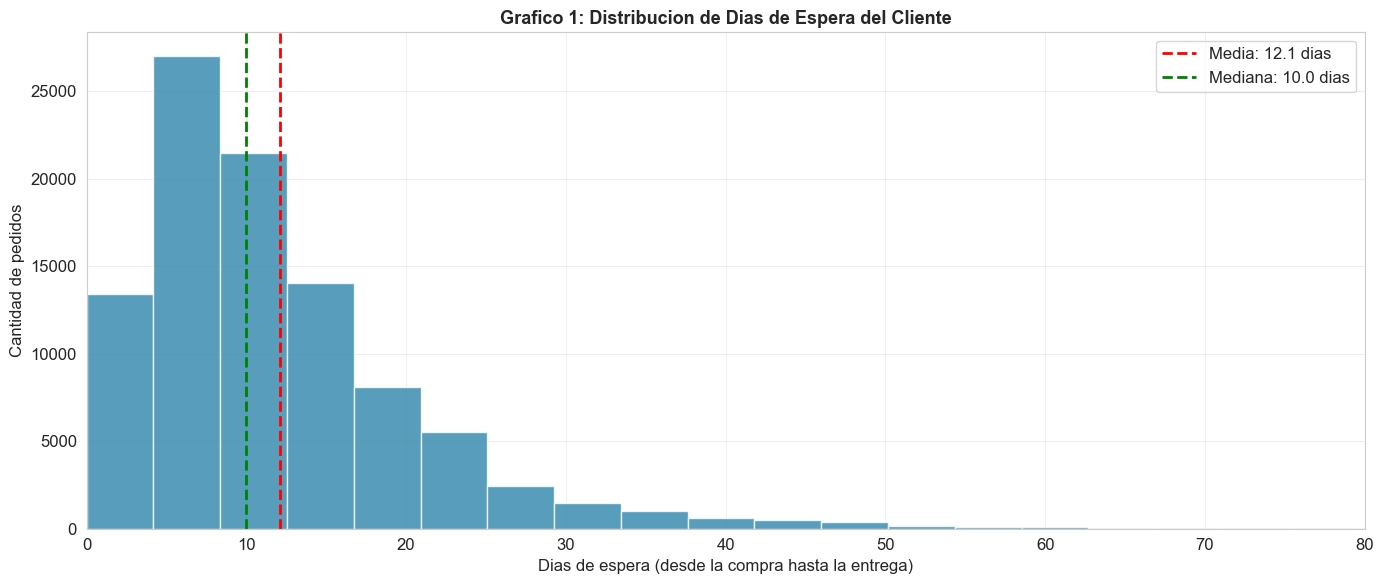

In [8]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.hist(df_orders['dias_espera'], bins=50, color='#2E86AB', edgecolor='white', alpha=0.8)
ax.axvline(df_orders['dias_espera'].mean(), color='red', linestyle='--', 
                   linewidth=2, label=f'Media: {df_orders["dias_espera"].mean():.1f} dias')
ax.axvline(df_orders['dias_espera'].median(), color='green', linestyle='--', 
                   linewidth=2, label=f'Mediana: {df_orders["dias_espera"].median():.1f} dias')
ax.set_title('Grafico 1: Distribucion de Dias de Espera del Cliente', fontsize=13, fontweight='bold')
ax.set_xlabel('Dias de espera (desde la compra hasta la entrega)')
ax.set_ylabel('Cantidad de pedidos')
ax.set_xlim(0, 80)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# GRAFICO 2: Pedidos a Tiempo vs Atrasados

#### Muestra la proporcion de pedidos que llegaron dentro del plazo estimado versus los que se atrasaron, usando la nueva variable binaria.

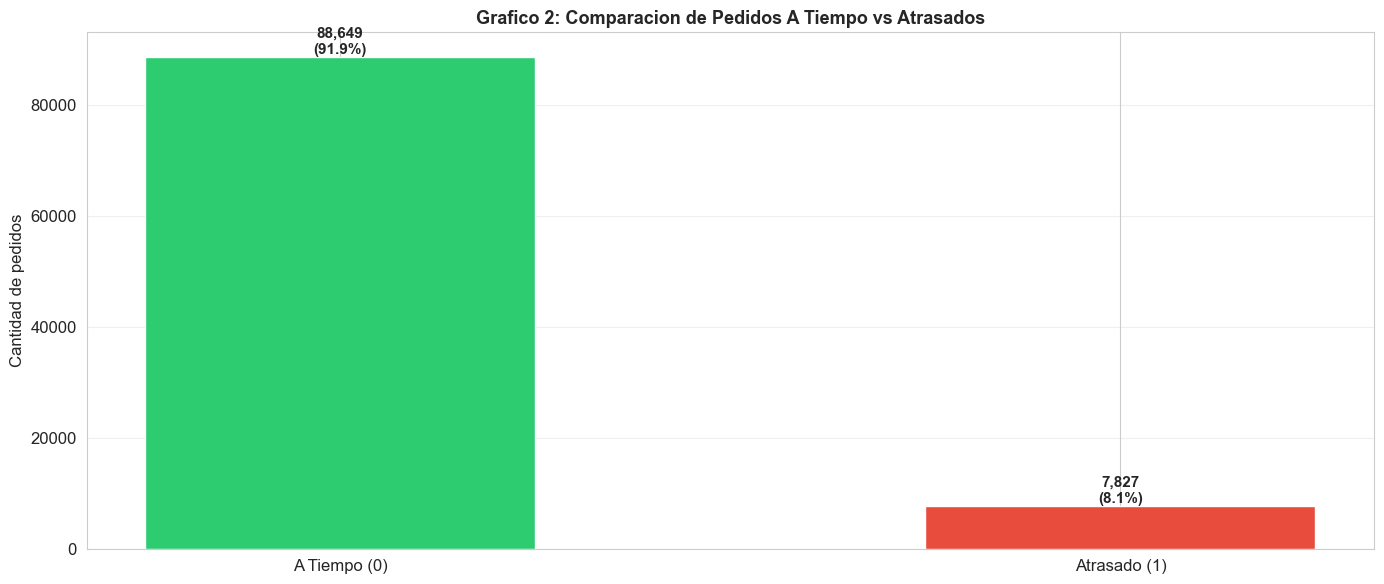

In [9]:
fig, ax = plt.subplots(figsize=(14, 6))
conteo = df_orders['es_atrasado'].value_counts().sort_index()
colores_barras = ['#2ECC71', '#E74C3C']
etiquetas = ['A Tiempo (0)', 'Atrasado (1)']
valores = [conteo.get(0, 0), conteo.get(1, 0)]

barras = ax.bar(etiquetas, valores, color=colores_barras, edgecolor='white', width=0.5)
# Agregamos el porcentaje sobre cada barra
for barra, valor in zip(barras, valores):
    porcentaje = valor / total * 100
    ax.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 500,
                    f'{valor:,}\n({porcentaje:.1f}%)', ha='center', fontsize=11, fontweight='bold')

ax.set_title('Grafico 2: Comparacion de Pedidos A Tiempo vs Atrasados', fontsize=13, fontweight='bold')
ax.set_ylabel('Cantidad de pedidos')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


# GRAFICO 3: Distribucion del Costo Total por Item

#### Muestra como se distribuye el gasto real de los clientes (precio + envio).
#### Permite identificar rangos de precio mas comunes y outliers.

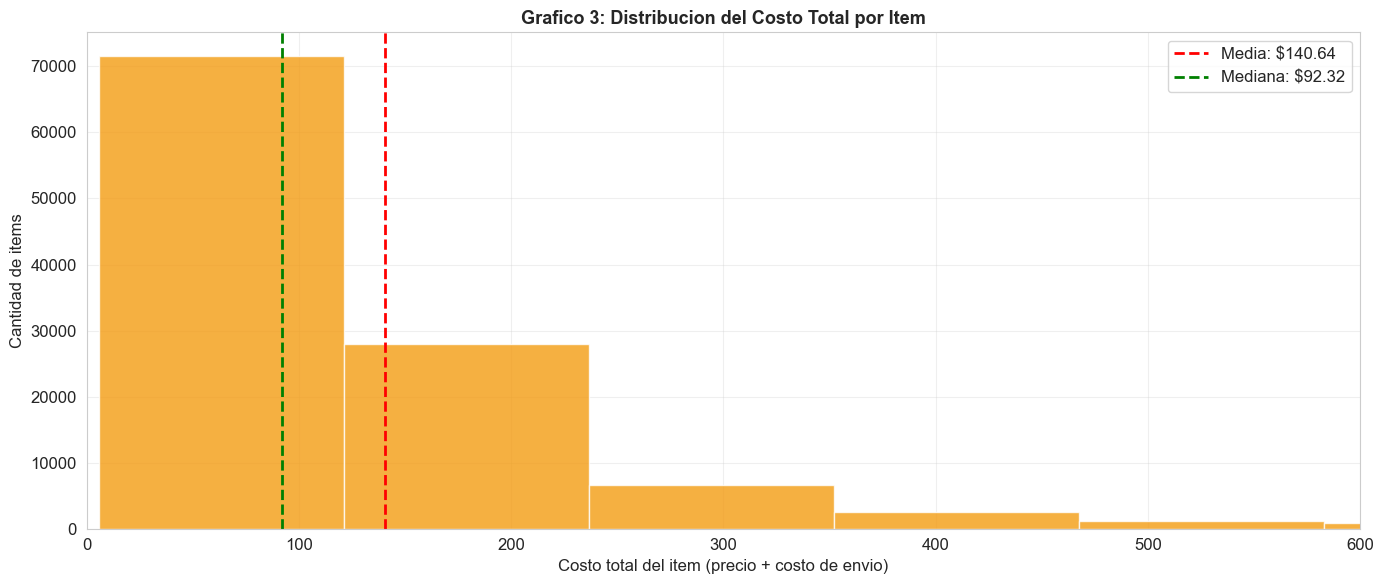

In [10]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.hist(df_items['costo_total_item'], bins=60, color='#F39C12', edgecolor='white', alpha=0.8)
ax.axvline(df_items['costo_total_item'].mean(), color='red', linestyle='--', 
                   linewidth=2, label=f'Media: ${df_items["costo_total_item"].mean():.2f}')
ax.axvline(df_items['costo_total_item'].median(), color='green', linestyle='--', 
                   linewidth=2, label=f'Mediana: ${df_items["costo_total_item"].median():.2f}')
ax.set_title('Grafico 3: Distribucion del Costo Total por Item', fontsize=13, fontweight='bold')
ax.set_xlabel('Costo total del item (precio + costo de envio)')
ax.set_ylabel('Cantidad de items')
ax.set_xlim(0, 600)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# GRAFICO 4: Relacion Precio vs Costo de Envio

#### Grafico de dispersion que muestra la relacion entre el precio del producto y el costo de envio asociado. Ayuda a entender si productos mas caros tienden a tener envios mas costosos.

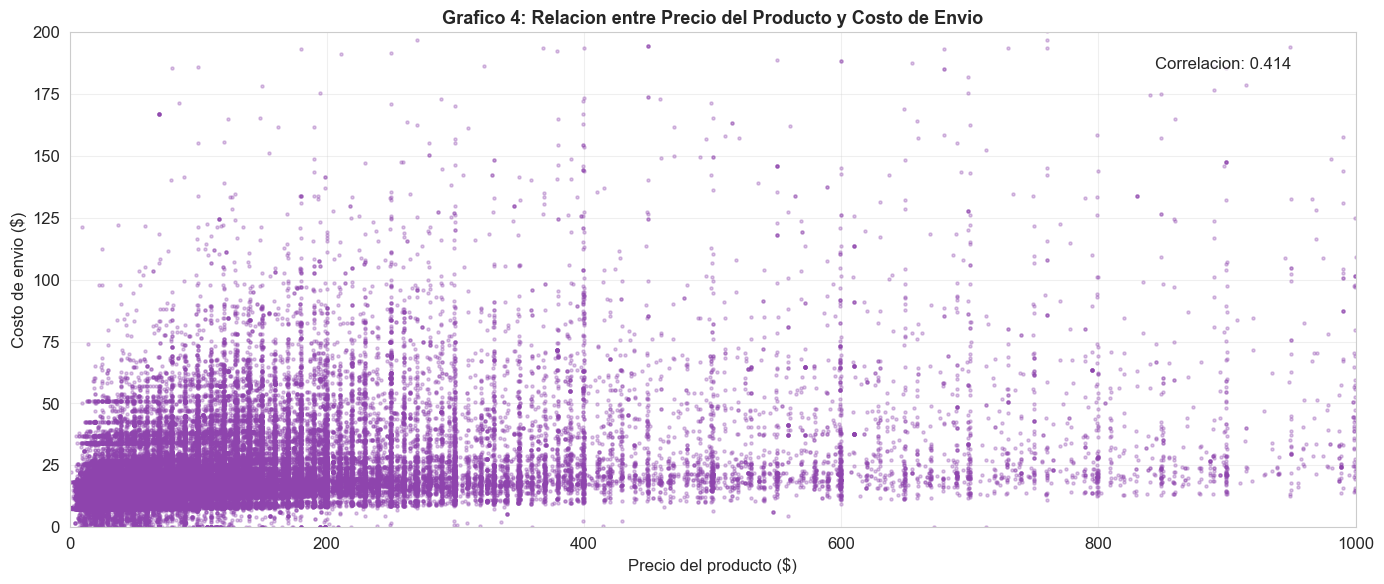

In [11]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.scatter(df_items['price'], df_items['freight_value'], 
                   alpha=0.3, s=5, color='#8E44AD')
ax.set_title('Grafico 4: Relacion entre Precio del Producto y Costo de Envio', 
                     fontsize=13, fontweight='bold')
ax.set_xlabel('Precio del producto ($)')
ax.set_ylabel('Costo de envio ($)')
ax.set_xlim(0, 1000)
ax.set_ylim(0, 200)
ax.grid(True, alpha=0.3)
correlacion = df_items['price'].corr(df_items['freight_value'])
ax.text(0.95, 0.95, f'Correlacion: {correlacion:.3f}', 
                transform=ax.transAxes, ha='right', va='top', 
                fontsize=12, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.tight_layout()
plt.show()

### Gráfico 5: Boxplot de Días de Espera según Atraso

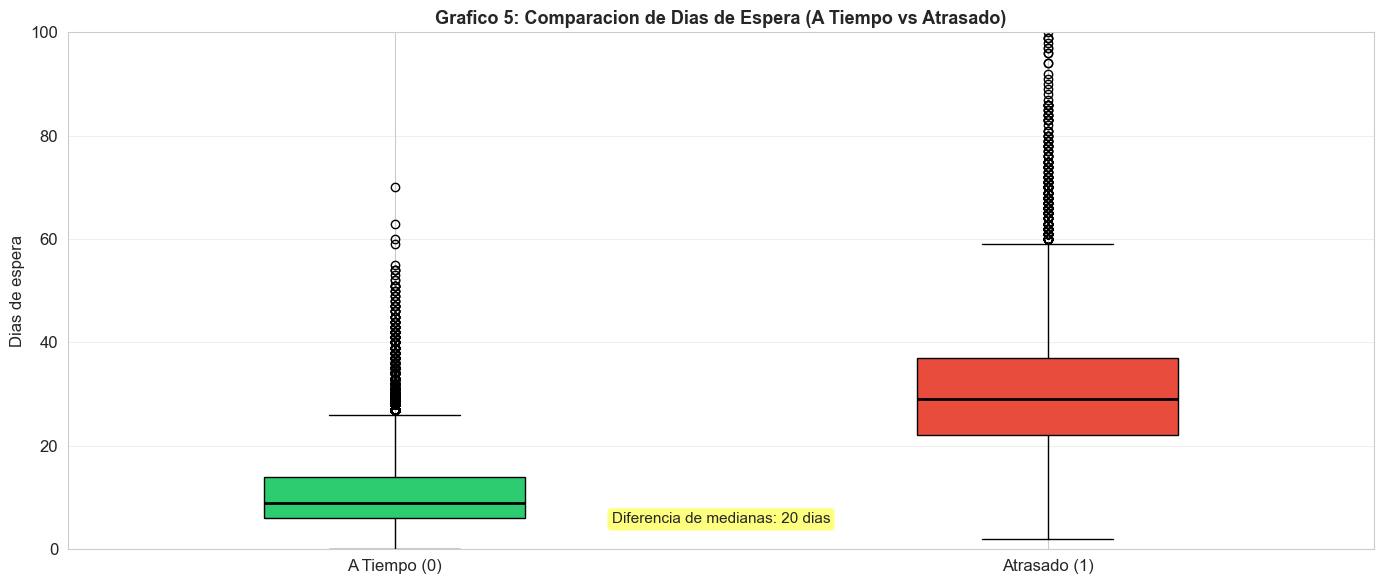

In [12]:
fig, ax = plt.subplots(figsize=(14, 6))
data_boxplot = [df_orders[df_orders['es_atrasado'] == 0]['dias_espera'],
                df_orders[df_orders['es_atrasado'] == 1]['dias_espera']]
bp = ax.boxplot(data_boxplot, patch_artist=True, widths=0.4,
                medianprops=dict(color='black', linewidth=2))
bp['boxes'][0].set_facecolor('#2ECC71')
bp['boxes'][1].set_facecolor('#E74C3C')
ax.set_xticklabels(['A Tiempo (0)', 'Atrasado (1)'])
ax.set_title('Grafico 5: Comparacion de Dias de Espera (A Tiempo vs Atrasado)', 
             fontsize=13, fontweight='bold')
ax.set_ylabel('Dias de espera')
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3, axis='y')
tiempo_a_tiempo = df_orders[df_orders['es_atrasado'] == 0]['dias_espera'].median()
tiempo_atrasado = df_orders[df_orders['es_atrasado'] == 1]['dias_espera'].median()
ax.text(0.5, 0.05, f'Diferencia de medianas: {tiempo_atrasado - tiempo_a_tiempo:.0f} dias',
        transform=ax.transAxes, ha='center', fontsize=11,
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))
plt.tight_layout()
plt.show()

In [13]:
print('---------------------------------------------\n  INGENIERIA DE CARACTERISTICAS COMPLETADA\n---------------------------------------------')
print(f'\nResumen final:')
print(f'  - Dataset ordenes: {df_orders.shape[0]:,} registros con {df_orders.shape[1]} columnas')
print(f'  - Dataset items: {df_items.shape[0]:,} registros con {df_items.shape[1]} columnas')
print(f'  - Nuevas variables creadas: 3 (dias_espera, es_atrasado, costo_total_item)')
print(f'  - Graficos generados: 5')

---------------------------------------------
  INGENIERIA DE CARACTERISTICAS COMPLETADA
---------------------------------------------

Resumen final:
  - Dataset ordenes: 96,476 registros con 10 columnas
  - Dataset items: 112,650 registros con 8 columnas
  - Nuevas variables creadas: 3 (dias_espera, es_atrasado, costo_total_item)
  - Graficos generados: 5


---
## Conclusiones de la Parte 3

En esta seccion se aplicaron exitosamente tecnicas de ingenieria de caracteristicas:

1. **Transformacion matematica de fechas:** Se creo `dias_espera` restando fechas para obtener un valor numerico util.
2. **Variable binaria condicional:** Se creo `es_atrasado` mediante una comparacion logica entre fechas reales y estimadas.
3. **Agregacion matematica:** Se creo `costo_total_item` sumando precio y envio, consolidando el gasto real.

Estas tres nuevas variables enriquecen el dataset original y proporcionan informacion valiosa que los algoritmos de Machine Learning podran aprovechar para generar mejores predicciones.